# Proyecto Integrador - Equipo 32
## Avance 4: Modelos de Árboles con Predicción Periódica (Independiente)
### Autores: Luis Mauricio Castro Gutiérrez, Gerardo Miguel Pérez Solis, Amiel Joel Rosete Islas

En este notebook experimentaremos con modelos independientes por cada período (1 mes, 2 meses y 3 meses a futuro) utilizando algoritmos de regresión basados en árboles: **XGBoost, LightGBM y Random Forest**. 

Adicionalmente, se incluyen nuevas **variables exógenas**:
1. **Isolation Forest Score**: Indicador multivariante de anomalías.
2. **Bayesian Hierarchical Score**: Probabilidad anómala obtenida vía distribución predictiva Poisson-Gamma.
3. **Vacunas con desfase**: Datos totales de vacunación con desfase dinámico para medir su impacto retardado, recortando las muestras sin datos.

In [21]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import nbinom as nbinom_dist
from sklearn.ensemble import IsolationForest, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
np.seterr(divide="ignore", invalid="ignore")
warnings.filterwarnings("ignore")

## 1. Carga de Datos y Variables Exógenas

Aquí cargaremos el dataset principal (`df_fe`) y el de vacunas. Evaluaremos los Scores de Anómalia que sirvieron de detector en bases pasadas para incluirlos como características al modelo predictivo.

In [22]:
base_path = Path("../../../..") / "data" / "processed"

# Dataset de Features (Ingeniería previa)
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# Dataset original con los totales de dosis (Vacunas)
df_vacunas = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_vacunas["fecha"] = pd.to_datetime(
    df_vacunas["anio"].astype(str) + "-" + df_vacunas["mes"].astype(str) + "-01"
)
df_vacunas = df_vacunas.sort_values("fecha").reset_index(drop=True)

df_fe["brote"] = (df_fe["casos_sarampion"] > 0).astype(int)
df_vacunas["brote"] = (df_vacunas["casos_sarampion"] > 0).astype(int)

# 1. Feature de Isolation Forest
exclude_cols = {"fecha", "anio", "mes", "casos_sarampion", "brote"}
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

# Ajustaremos la anomalía usando entrenamiento (< 2019) como base para no filtrar información del futuro
train_mask = df_fe["anio"] < 2019
X_train_if = df_fe.loc[train_mask, feature_cols].values
cont_rate = max(df_fe.loc[train_mask, "brote"].mean(), 0.01)

iso_forest = IsolationForest(n_estimators=200, contamination=cont_rate, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_if)

# Mayor score (al multiplicar por negativo) = Más anómalo
df_fe["isolation_forest_score"] = -iso_forest.decision_function(df_fe[feature_cols].values)

# 2. Feature Bayesiana (Poisson-Gamma)
def calcular_bayesian_score(df, split_year=2019):
    train_mask = df["anio"] < split_year
    train_raw = df[train_mask]
    
    global_mean_train = train_raw["casos_sarampion"].mean()
    global_var_train  = train_raw["casos_sarampion"].var()

    if global_var_train > global_mean_train and global_mean_train > 0:
        beta_0  = global_mean_train / max(global_var_train, 1e-6)
        alpha_0 = global_mean_train * beta_0
    else:
        alpha_0, beta_0 = 0.5, 0.5
        
    posteriors_by_month = {}
    for mes in range(1, 13):
        month_data = train_raw[train_raw["mes"] == mes]["casos_sarampion"]
        n_m    = len(month_data)
        sum_ym = int(month_data.sum())
        alpha_post = alpha_0 + sum_ym
        beta_post  = beta_0 + n_m
        posteriors_by_month[mes] = (alpha_post, beta_post)

    bayes_pvalues = np.zeros(len(df))
    for idx in range(len(df)):
        mes   = int(df.iloc[idx]["mes"])
        y_obs = int(df.iloc[idx]["casos_sarampion"])
        alpha_post, beta_post = posteriors_by_month[mes]
        
        r = alpha_post
        p = beta_post / (1.0 + beta_post)
        if y_obs > 0:
            p_value = 1.0 - nbinom_dist.cdf(y_obs - 1, r, p)
        else:
            p_value = 1.0
        bayes_pvalues[idx] = p_value
        
    return 1.0 - bayes_pvalues

df_fe["bayesian_score"] = calcular_bayesian_score(df_vacunas)

print("Exógenas Isolation Forest y Bayesian agregadas a df_fe.")


Exógenas Isolation Forest y Bayesian agregadas a df_fe.


## 2. Inserción de Vacunas con Desfase (Variable Editable)
Integramos un desfase en meses. El parámetro `MESES_DESFASE` es editable.

In [23]:
MESES_DESFASE = 2  # <--- Editable a 1, 2, 3 meses u otro.

def integrar_vacunas_con_desfase(df_principal, df_vac, desfase_meses=0):
    df_vac_lag = df_vac.copy()
    
    # Desplazamos las fechas sumándole los meses de desfase para empatar la dosis del pasado al mes actual
    df_vac_lag["fecha_join"] = df_vac_lag["fecha"] + pd.DateOffset(months=desfase_meses)
    
    col_name = f"total_dosis_lag_{desfase_meses}m"
    df_vac_lag = df_vac_lag[["fecha_join", "total_dosis"]].rename(
        columns={"total_dosis": col_name}
    )
    
    df_res = pd.merge(df_principal, df_vac_lag, left_on="fecha", right_on="fecha_join", how="left")
    df_res.drop(columns=["fecha_join"], inplace=True)
    
    # Borrar los meses que no tengan datos de vacunas como se solicita, para mantener datos completos
    df_res.dropna(subset=[col_name], inplace=True)
    
    return df_res.reset_index(drop=True)

df_model = integrar_vacunas_con_desfase(df_fe, df_vacunas, desfase_meses=MESES_DESFASE)
print("Forma del dataset de modelación luego de dropear NaNs por desfase:", df_model.shape)


Forma del dataset de modelación luego de dropear NaNs por desfase: (166, 30)


## 3. Train-Test Split por Periodos Editable
Separamos estrictamente la información cronológica antes de la construcción de objetivos (targets).
Por ser un problema de **Series de Tiempo**, debemos utilizar la información pasada para predecir a 1, 2 o 3 meses. El split previene el *data leakage* (fuga de datos futuros al pasado).

In [24]:
# Editable period limits (Entrenamiento vs Prueba)
TRAIN_START_YEAR = 2010
TRAIN_END_YEAR = 2018 # <=2018 is train
TEST_START_YEAR = 2019
TEST_END_YEAR = 2023 # >=2019 is test

# Limit the dataset globally to the desired max spans
df_model = df_model[(df_model["anio"] >= TRAIN_START_YEAR) & (df_model["anio"] <= TEST_END_YEAR)].copy()

# Features a excluir en los predictores (Xs)
cols_to_exclude = {"fecha", "anio", "mes", "casos_sarampion", "brote"}
model_features = [c for c in df_model.columns if c not in cols_to_exclude]

print(f"Número de predictores finales: {len(model_features)}")


Número de predictores finales: 25


## 4. Time-Series Forecasting: Direct Multi-step por Horizontes
Crearemos un ciclo para construir y evaluar modelos XGBoost, LightGBM y Random Forest independientemente para predecir a `h` meses (1, 2 y 3 meses).

En el modelado *Direct Forecasting*, para un horizonte `h`, desplazamos nuestro objetivo `h` pasos hacia atrás: predecimos `casos_sarampion_{t+h}` usando la información de las regresoras en el instante `t`.

In [25]:
# Lista de horizontes de predicción en meses
horizontes = [1, 2, 3]

# Inicializar modelos
modelos = {
    "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

resultados_globales = []

for h in horizontes:
    print(f"\n{'='*50}")
    print(f" MODELANDO HORIZONTE: {h} MESES AL FUTURO (t+{h})")
    print(f"{'='*50}")
    
    # Creamos un dataset específico para este horizonte
    df_h = df_model.copy()
    
    # Objetivo desplazado: el objetivo es el caso_sarampion del tiempo que ocurrirá h meses después.
    target_col = f"target_h{h}"
    df_h[target_col] = df_h["casos_sarampion"].shift(-h)
    
    # Borramos los últimos h meses, ya que no tendremos horizonte de evaluación final en la historia (NaNs)
    df_h.dropna(subset=[target_col], inplace=True)
    
    # Partición temporal
    train_mask = df_h["anio"] <= TRAIN_END_YEAR
    test_mask = df_h["anio"] >= TEST_START_YEAR
    
    train_df = df_h[train_mask]
    test_df = df_h[test_mask]
    
    X_train = train_df[model_features].values
    y_train = train_df[target_col].values
    
    X_test = test_df[model_features].values
    y_test = test_df[target_col].values
    
    for nombre_modelo, modelo in modelos.items():
        # Fit
        modelo.fit(X_train, y_train)
        
        # Predict on Test
        preds = modelo.predict(X_test)
        preds = np.maximum(preds, 0) # Clip a cero si el modelo regresa valores negativos en un número real de casos
        
        # Metrics
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        
        print(f"[{nombre_modelo}] Horizonte {h}m -> MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        
        resultados_globales.append({
            "Horizonte (Meses)": h,
            "Modelo": nombre_modelo,
            "MAE": mae,
            "RMSE": rmse
        })
        
        # Graficamos sólo Random Forest para no saturar si lo desea el usuario, o en este caso los graficaremos como muestra final



 MODELANDO HORIZONTE: 1 MESES AL FUTURO (t+1)
[XGBoost] Horizonte 1m -> MAE: 4.5118 | RMSE: 15.1445
[LightGBM] Horizonte 1m -> MAE: 4.3364 | RMSE: 13.4378
[Random Forest] Horizonte 1m -> MAE: 4.9497 | RMSE: 13.4249

 MODELANDO HORIZONTE: 2 MESES AL FUTURO (t+2)
[XGBoost] Horizonte 2m -> MAE: 5.4735 | RMSE: 16.4200
[LightGBM] Horizonte 2m -> MAE: 4.9994 | RMSE: 14.7000
[Random Forest] Horizonte 2m -> MAE: 4.8818 | RMSE: 14.6527

 MODELANDO HORIZONTE: 3 MESES AL FUTURO (t+3)
[XGBoost] Horizonte 3m -> MAE: 3.9842 | RMSE: 14.8018
[LightGBM] Horizonte 3m -> MAE: 4.5164 | RMSE: 14.7075
[Random Forest] Horizonte 3m -> MAE: 4.0416 | RMSE: 14.7739


## 5. Resumen de Modelos a Distintos Horizontes y Comparativa Final

,Horizonte (Meses),Modelo,MAE,RMSE
2,1,Random Forest,4.949709,13.424940
1,1,LightGBM,4.336351,13.437752
0,1,XGBoost,4.511770,15.144536
5,2,Random Forest,4.881764,14.652741
4,2,LightGBM,4.999417,14.699973
3,2,XGBoost,5.473545,16.420019
7,3,LightGBM,4.516361,14.707518
8,3,Random Forest,4.041579,14.773869
6,3,XGBoost,3.984217,14.801825


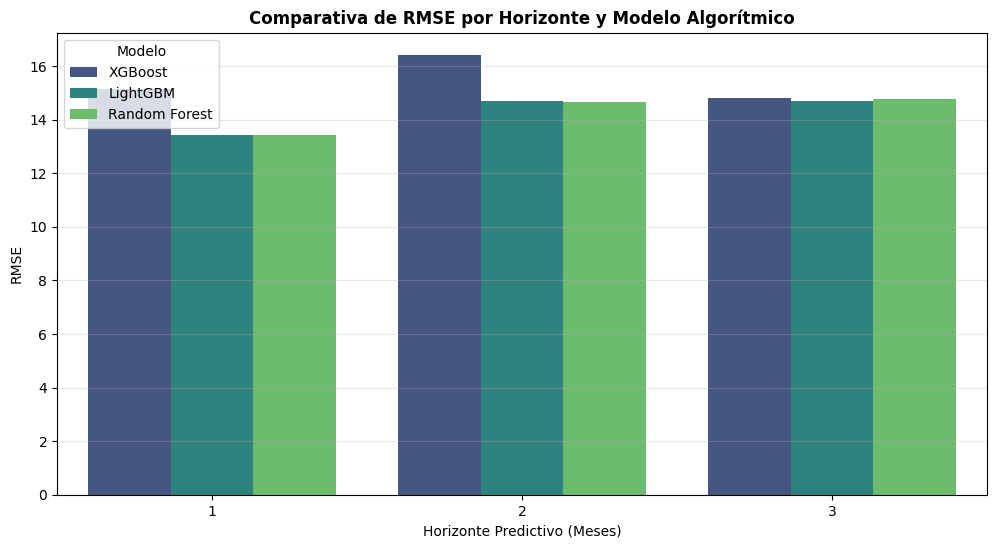

In [26]:
df_res = pd.DataFrame(resultados_globales)
display(df_res.sort_values(by=["Horizonte (Meses)", "RMSE"]))

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x="Horizonte (Meses)", y="RMSE", hue="Modelo", palette="viridis")
plt.title("Comparativa de RMSE por Horizonte y Modelo Algorítmico", fontweight="bold")
plt.ylabel("RMSE")
plt.xlabel("Horizonte Predictivo (Meses)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()
